In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading the dataset
df = pd.read_csv("Amazon_Sale_Report_cleaned.csv", low_memory=False)

In [2]:
df

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,Easy Ship
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,128970,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,...,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
128971,128971,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,...,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
128972,128972,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,...,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship
128973,128973,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,...,1,INR,1199.00,Halol,Gujarat,389350.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Easy Ship


In [3]:
# Dataset Overview

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows")
print(df.head())

print("\nDataset Information")
print(df.info())

Dataset Shape: (128975, 23)

First 5 Rows
   index             Order ID        Date                        Status  \
0      0  405-8078784-5731545  2022-04-30                     Cancelled   
1      1  171-9198151-1101146  2022-04-30  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  2022-04-30                       Shipped   
3      3  403-9615377-8133951  2022-04-30                     Cancelled   
4      4  407-1069790-7240320  2022-04-30                       Shipped   

  Fulfilment Sales Channel ship-service-level    Style              SKU  \
0   Merchant     Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant     Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon     Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant     Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon     Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... Qty currency  Amount    ship-city 

This gives the number of rows and columns, displays the first few records, and shows the data types of each column.

In [4]:
# Summary Statistics

print(df.describe())

               index            Qty         Amount  ship-postal-code
count  128975.000000  128975.000000  128975.000000     128975.000000
mean    64487.000000       0.904431     645.928694     463899.030052
std     37232.019822       0.313354     272.778829     191498.352590
min         0.000000       0.000000       0.000000     110001.000000
25%     32243.500000       1.000000     459.000000     382421.000000
50%     64487.000000       1.000000     605.000000     500033.000000
75%     96730.500000       1.000000     771.000000     600024.000000
max    128974.000000      15.000000    5584.000000     989898.000000


Displays statistical information such as mean, minimum, maximum, and standard deviation for numerical columns.

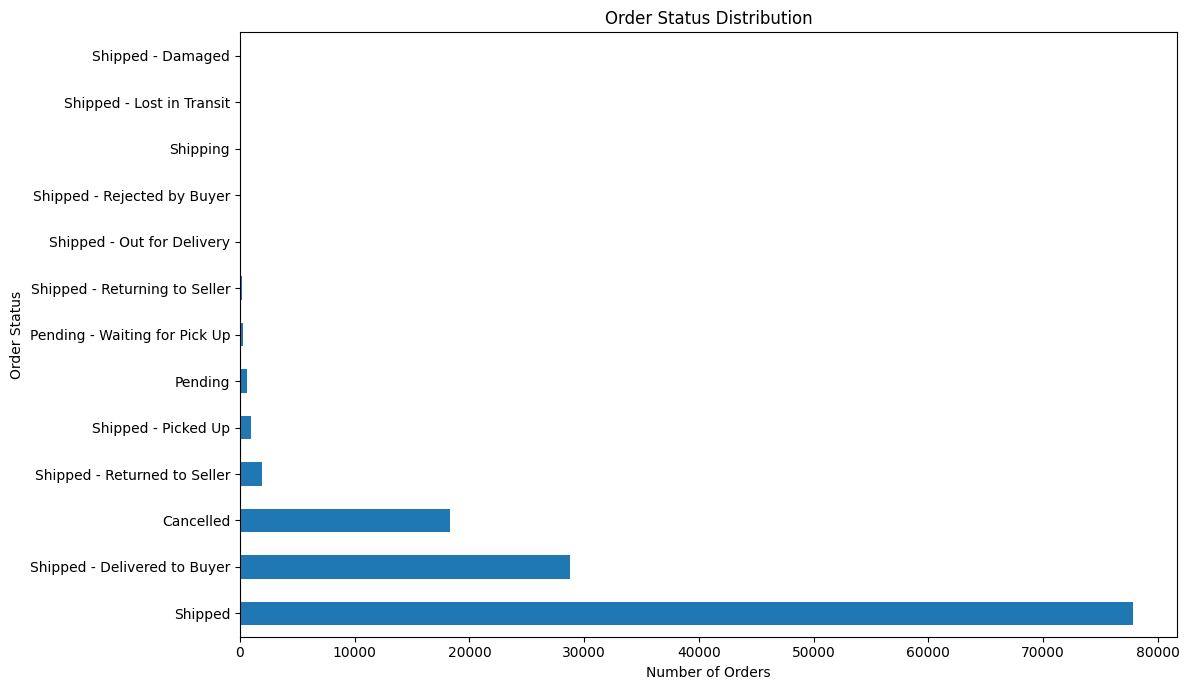

In [5]:
# Order Status Distribution

status_counts = df["Status"].value_counts()

plt.figure(figsize=(12,7))

status_counts.plot(kind="barh")

plt.title("Order Status Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")

plt.tight_layout()
plt.show()

Shows how many orders fall under each order status (e.g., Shipped, Cancelled, Returned).

Category
Set              41165534.03
kurta            23211346.70
Western Dress    11697652.69
Top               5624277.30
Ethnic Dress       831147.66
Blouse             485633.18
Bottom             162767.98
Saree              129378.76
Dupatta               915.00
Name: Amount, dtype: float64


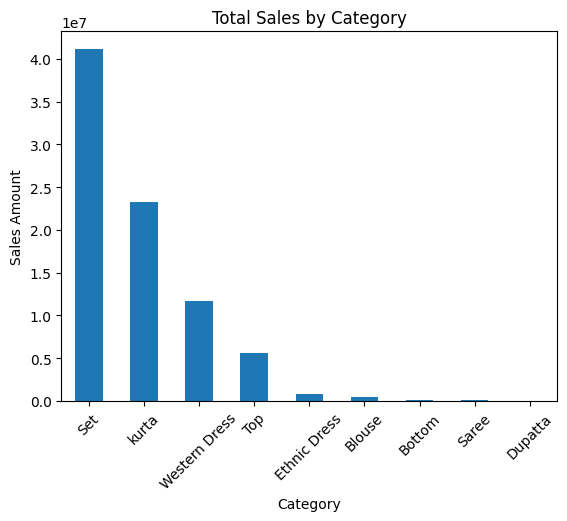

In [6]:
# Sales by Category

category_sales = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

print(category_sales)

category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.show()

Shows which product categories generated the highest sales.

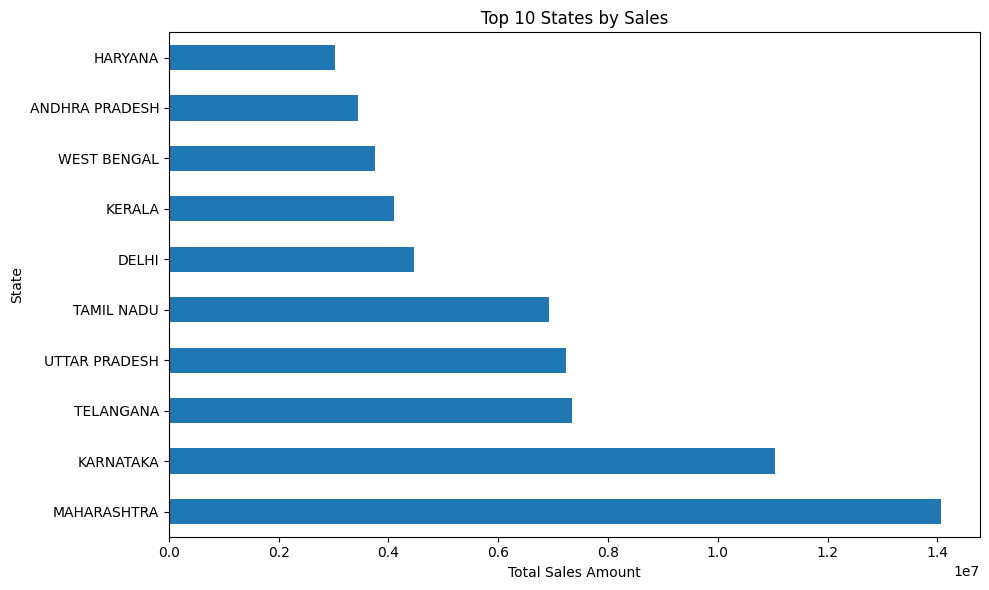

In [7]:
# Top 10 states by sales

state_sales = df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

state_sales.plot(kind="barh")

plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales Amount")
plt.ylabel("State")

plt.tight_layout()
plt.show()

Displays the states that contributed the highest sales.

Fulfilment
Amazon      89698
Merchant    39277
Name: count, dtype: int64


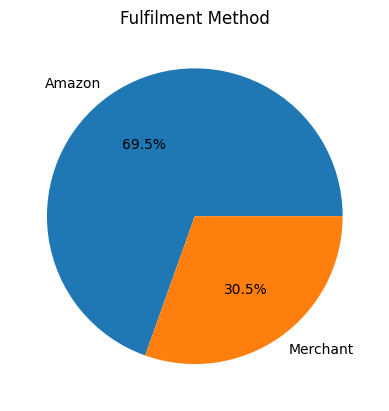

In [8]:
# Fulfilment Method

fulfilment = df["Fulfilment"].value_counts()

print(fulfilment)

fulfilment.plot(kind="pie", autopct="%1.1f%%")
plt.title("Fulfilment Method")
plt.ylabel("")
plt.show()

The Fulfilment column in the Amazon Sale Report dataset indicates who was responsible for processing and shipping the customer's order.

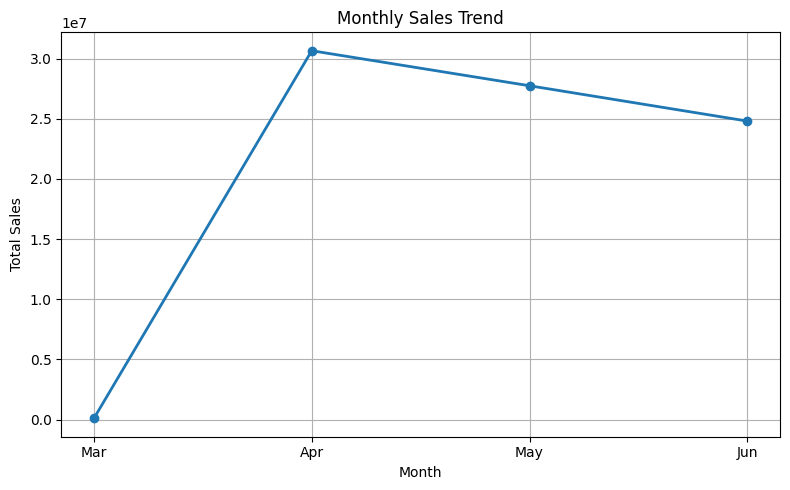

In [9]:
# Monthly sales trend

df["Date"] = pd.to_datetime(df["Date"])

month_order = ["Mar", "Apr", "May", "Jun"]

monthly_sales = (
    df.groupby(df["Date"].dt.strftime("%b"))["Amount"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(8,5))

plt.plot(monthly_sales.index, monthly_sales.values, marker='o', linewidth=2)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)

plt.tight_layout()
plt.show()

Shows how sales changed over different months.

Category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64


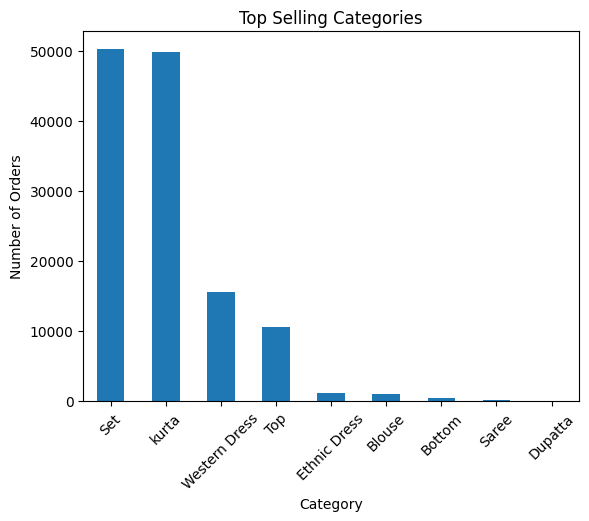

In [10]:
# Top 10 selling categories

top_category = df["Category"].value_counts().head(10)

print(top_category)

top_category.plot(kind="bar")
plt.title("Top Selling Categories")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

Shows which product categories received the most orders.

The exploratory data analysis provided an overview of the Amazon sales dataset. The analysis identified the most common order statuses, highest-selling product categories, top-performing states, fulfilment methods, and monthly sales trends. These insights help in understanding customer purchasing patterns and sales performance, providing a solid foundation for further analysis or predictive modeling.